<a href="https://colab.research.google.com/github/sgl13/Machine_Learning/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression**

 statistical algorithm used for classification tasks—predicting categorical outcomes based on one or more independent input features. Unlike linear regression, which predicts continuous numerical values, logistic regression estimates the probability that a given input belongs to a specific class or category

**Binary Classification:**

The most common use case, where the target variable has two discrete outcomes (e.g., Yes/No, 1/0, Admitted/Not Admitted, Pass/Fail).

**The Sigmoid Function:** Converts linear combination outputs into a probability value bounded strictly between 0 and 1:$$p = \frac{1}{1 + e^{-z}}$$(where $z = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$)




**Decision Boundary:** A calculated threshold (typically set at 0.5) used to assign predictions. If the predicted probability $p \ge 0.5$, the observation is classified as 1; if $p < 0.5$, it is classified as 0.

In [1]:
#Build a predictive model to predict weather a student get admission in college
#based on given below data
#what type of classification we need to predict?---> it is a binary classification
#if there is a binary classification prediction what type of algorithm we use -->Logistic regression

In [2]:
import pandas as pd
candidates = {'gmat': [780,750,690,710,680,730,690,720,740,690,610,690,710,680,770,610,580,650,540,590,620,600,550,550,570,670,660,580,650,660,640,620,660,660,680,650,670,580,590,690],
              'gpa': [4,3.9,3.3,3.7,3.9,3.7,2.3,3.3,3.3,1.7,2.7,3.7,3.7,3.3,3.3,3,2.7,3.7,2.7,2.3,3.3,2,2.3,2.7,3,3.3,3.7,2.3,3.7,3.3,3,2.7,4,3.3,3.3,2.3,2.7,3.3,1.7,3.7],
              'work_experience': [3,4,3,5,4,6,1,4,5,1,3,5,6,4,3,1,4,6,2,3,2,1,4,1,2,6,4,2,6,5,1,2,4,6,5,1,2,1,4,5],
              'admitted': [1,1,0,1,0,1,0,1,1,0,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,1,1,0,0,1,1,1,0,0,0,0,1]
              }

In [3]:
#convert the above data into dataframe
df = pd.DataFrame(candidates,columns=['gmat','gpa','work_experience','admitted'])
print(df)

    gmat  gpa  work_experience  admitted
0    780  4.0                3         1
1    750  3.9                4         1
2    690  3.3                3         0
3    710  3.7                5         1
4    680  3.9                4         0
5    730  3.7                6         1
6    690  2.3                1         0
7    720  3.3                4         1
8    740  3.3                5         1
9    690  1.7                1         0
10   610  2.7                3         0
11   690  3.7                5         1
12   710  3.7                6         1
13   680  3.3                4         0
14   770  3.3                3         1
15   610  3.0                1         0
16   580  2.7                4         0
17   650  3.7                6         1
18   540  2.7                2         0
19   590  2.3                3         0
20   620  3.3                2         1
21   600  2.0                1         0
22   550  2.3                4         0
23   550  2.7   

In [4]:
df.isnull().sum()

,0
gmat,0
gpa,0
work_experience,0
admitted,0


In [5]:
df.describe()

,gmat,gpa,work_experience,admitted
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,3.095000,3.425000,0.475000
std,61.427464,0.631218,1.737778,0.505736
min,540.000000,1.700000,1.000000,0.000000
25%,607.500000,2.700000,2.000000,0.000000
50%,660.000000,3.300000,4.000000,0.000000
75%,690.000000,3.700000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


In [6]:
df.drop_duplicates()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0
5,730,3.7,6,1
6,690,2.3,1,0
7,720,3.3,4,1
8,740,3.3,5,1
9,690,1.7,1,0


**EDA**

EDA stands for Exploratory Data Analysis. It is the crucial initial step in data analysis and machine learning where we analyze and summarize data sets to understand their main characteristics, patterns, and relationships before building models.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


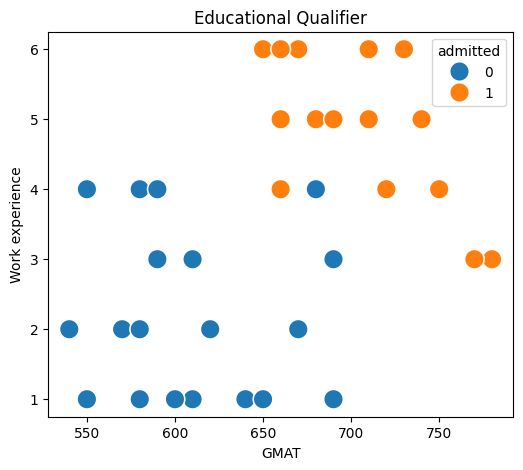

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(x ='gmat',y='work_experience',hue='admitted',data=df, s= 200)
plt.title('Educational Qualifier')
plt.xlabel('GMAT')
plt.ylabel('Work experience')
ax = plt.gca()    #gca means get the current axis

In [9]:
#there is a linear decision boundry we can good to go with the Logistic regression

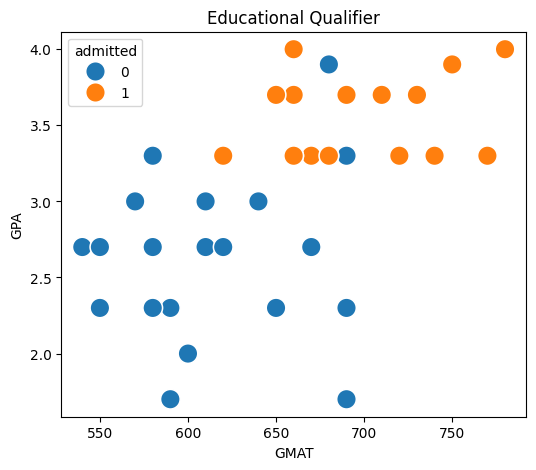

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x ='gmat',y='gpa',hue='admitted',data=df, s= 200)
plt.title('Educational Qualifier')
plt.xlabel('GMAT')
plt.ylabel('GPA')
ax = plt.gca()    #gca means get the current axis

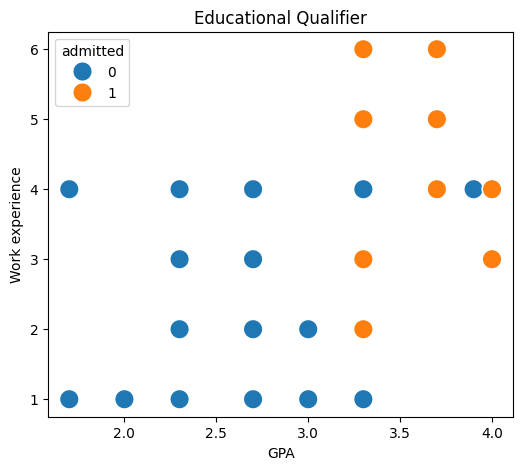

In [11]:
plt.figure(figsize=(6,5))
sns.scatterplot(x ='gpa',y='work_experience',hue='admitted',data=df, s= 200)
plt.title('Educational Qualifier')
plt.xlabel('GPA')
plt.ylabel('Work experience')
ax = plt.gca()    #gca means get the current axis

Data Jar

In [12]:
X = df[['gmat','gpa','work_experience']].values
y = df['admitted'].values

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25,random_state=0)

In [14]:
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred = logistic_regression.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 1])

In [15]:
logistic_regression.predict([[480,2.5,1]])

array([0])

In [16]:
logistic_regression.predict_proba([[650,3,3.5]])

array([[0.76952526, 0.23047474]])

In [17]:
logistic_regression.predict_proba(X_test)

array([[9.91609170e-01, 8.39083019e-03],
       [9.82687289e-01, 1.73127111e-02],
       [4.82914493e-02, 9.51708551e-01],
       [2.31230583e-01, 7.68769417e-01],
       [9.72097527e-01, 2.79024730e-02],
       [9.97315178e-01, 2.68482237e-03],
       [7.39231939e-02, 9.26076806e-01],
       [6.18364053e-02, 9.38163595e-01],
       [9.99411619e-01, 5.88381109e-04],
       [2.11029738e-01, 7.88970262e-01]])

In [18]:
logistic_regression.coef_

array([[0.03707553, 0.72109181, 1.2915195 ]])

In [19]:
logistic_regression.intercept_

array([-31.98831794])

In [20]:
from sklearn.metrics import accuracy_score,f1_score
f1_score(y_pred,y_test)
accuracy_score(y_pred,y_test)

0.8